In [1]:
# ambiente anaconda
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/YouTube/bin/python


## Dígitos ou caracteres escritos a mão

# Projeto 11: Rede Neural Convolucional MNIST

In [2]:
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
# coleta dos dados online
from torchvision import datasets
# transformação e carregamentos da imagem
import torchvision.transforms as transforms
torch.__version__

'2.8.0+cu128'

In [3]:
import sys
print(sys.version)

3.12.8 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:31:09) [GCC 11.2.0]


## Etapa 2: Base de dados

In [4]:
## semente para ter sempre o mesmo resultado
torch.manual_seed(123)

In [5]:
# download da imagem e vai converter para tensor
transform = transforms.ToTensor()

In [6]:
# dados 100% preparado para o pytorch, sem precisar converter para numpy a imagem e depois para o tensor, vai direto

In [7]:
# normalização, deixar em uma escala de 0 e 1.
# rede neural mais rápida
# divisão por 255

base de dados 100% preparada com os dados das figuras como Tensor (ToTensor())

e também com os dados normalizados 

In [8]:
#root salvar na imagem => .; criando para o train = True
#root salvar na imagem => .; criando para o train = False, para a base de teste

In [9]:
train = datasets.MNIST(root = '.', train = True, download=True, transform=transform)
test = datasets.MNIST(root = '.', train = False, download=True, transform=transform)

In [10]:
# download das imagens

In [11]:
train.data[0]
# primeiro registros das imagens, pixels, 0 é o preto, colorido é os outros números
# normalização das imagens de 0 a 255

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [12]:
train.data # matrizes

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

### Instância do louder, normalização da imagem

In [13]:
train.data.shape

torch.Size([60000, 28, 28])

In [14]:

print(f'quantidade de imagens {train.data.shape[0]}, {train.data.shape[1]} por {train.data.shape[2]}')

print(f'{train.data.shape[1]} pixels de largura e {train.data.shape[2]} de altura.')



quantidade de imagens 60000, 28 por 28
28 pixels de largura e 28 de altura.


In [15]:
print(f'Cada uma das imagens possuem um total de {28*28} pixels.')

Cada uma das imagens possuem um total de 784 pixels.


#### 784 pixels para a camada de entrada da rede neural.

Como trabalhamos com redes neurais convolucionais, haverá uma série de processamentos nesses 784 pixels. Processos de camadas, para reduzir a dimensionalidade.

In [16]:
# cada imagem ou matriz representa um número
train.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [17]:
len(train.targets) # quantidade de imagens

60000

In [18]:
# treinamento de 128 a 128 registros => batch_size
train_loader = torch.utils.data.DataLoader(train, batch_size=128)


In [19]:
test_loader = torch.utils.data.DataLoader(test, batch_size=128)

### visualizar a imagem 

In [20]:
# iter interação na base de dados train_loader
# view mudar as dimensões das imagens

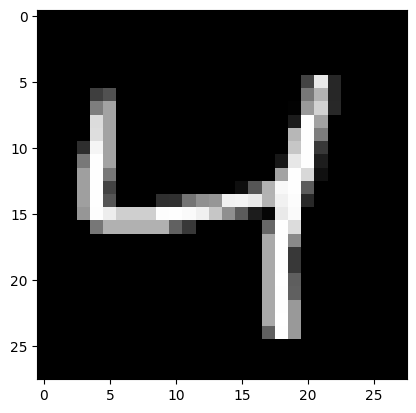

In [21]:
imagem = next(iter(train_loader))[0][2].view(28, 28) # (1, 1, 28, 28)
# imagem na escala cinza
plt.imshow(imagem, cmap='gray')

cmap =>

'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'winter', 'winter_r'

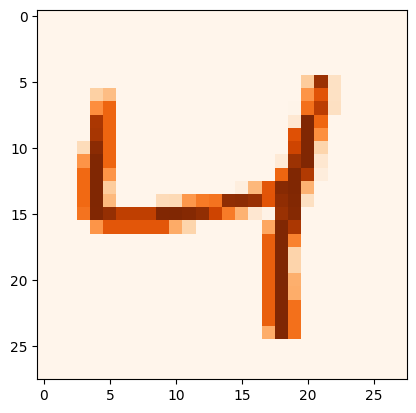

In [22]:
imagem = next(iter(train_loader))[0][2].view(28, 28) # (1, 1, 28, 28)

plt.imshow(imagem, cmap='Oranges')

loader, faz a divisão de batch_size, no exemplo de 128 para 128 imagens

retorna o batches, dados do treinamento em pixels e target (respostas reais que indicam qual número a imagem pertence). 

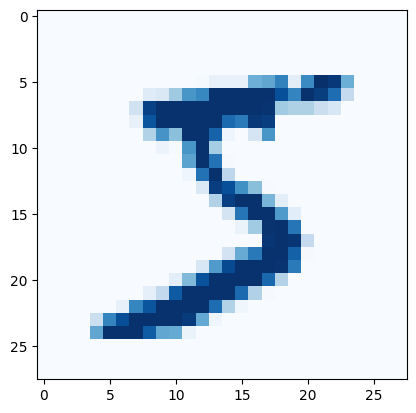

In [23]:
imagem = next(iter(train_loader))[0][0].view(28, 28) # (1, 1, 28, 28)
# imagem na escala azul
plt.imshow(imagem, cmap='Blues')

0 primeiro atributo previsores, e o segundo a a imagem [0][0].view()

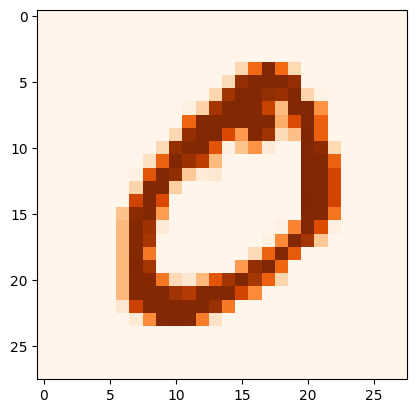

In [24]:
imagem = next(iter(train_loader))[0][1].view(28, 28) # (1, 1, 28, 28)
# (1 imagem, 1 filtro ou imagem (cinza é 1 canal de cor), 28 pixels altura, 28 pixels largura)
# imagem na escala laranja
plt.imshow(imagem, cmap='Oranges')

In [25]:
imagem.shape # 28 pixels de altura e 28 pixels de largura

torch.Size([28, 28])

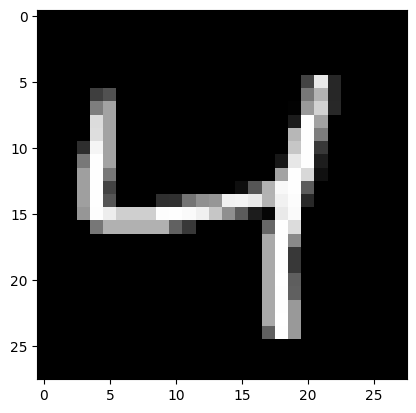

In [26]:
imagem = next(iter(train_loader))[0][2].view(28, 28) # (1, 1, 28, 28)
# (1 imagem, 1 filtro ou imagem (cinza é 1 canal de cor), 28 pixels altura, 28 pixels largura)
# imagem na escala cinza
plt.imshow(imagem, cmap='gray')

(array([669.,  10.,   7.,   9.,   8.,   5.,  27.,   5.,   8.,  36.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <BarContainer object of 10 artists>)

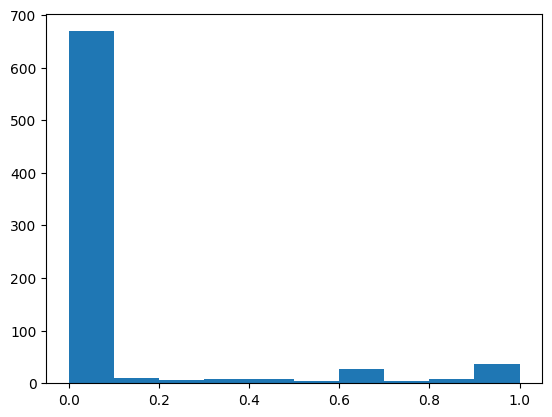

In [27]:
# view menos 1 (-1) para tirar a última dimensão do histograma
plt.hist(imagem.view(-1))

entre 0 e 1, do eixo x, submete os dados do train_loader, e vai fazer a normalização da imagem. 

## Etapa 3: Construção do modelo

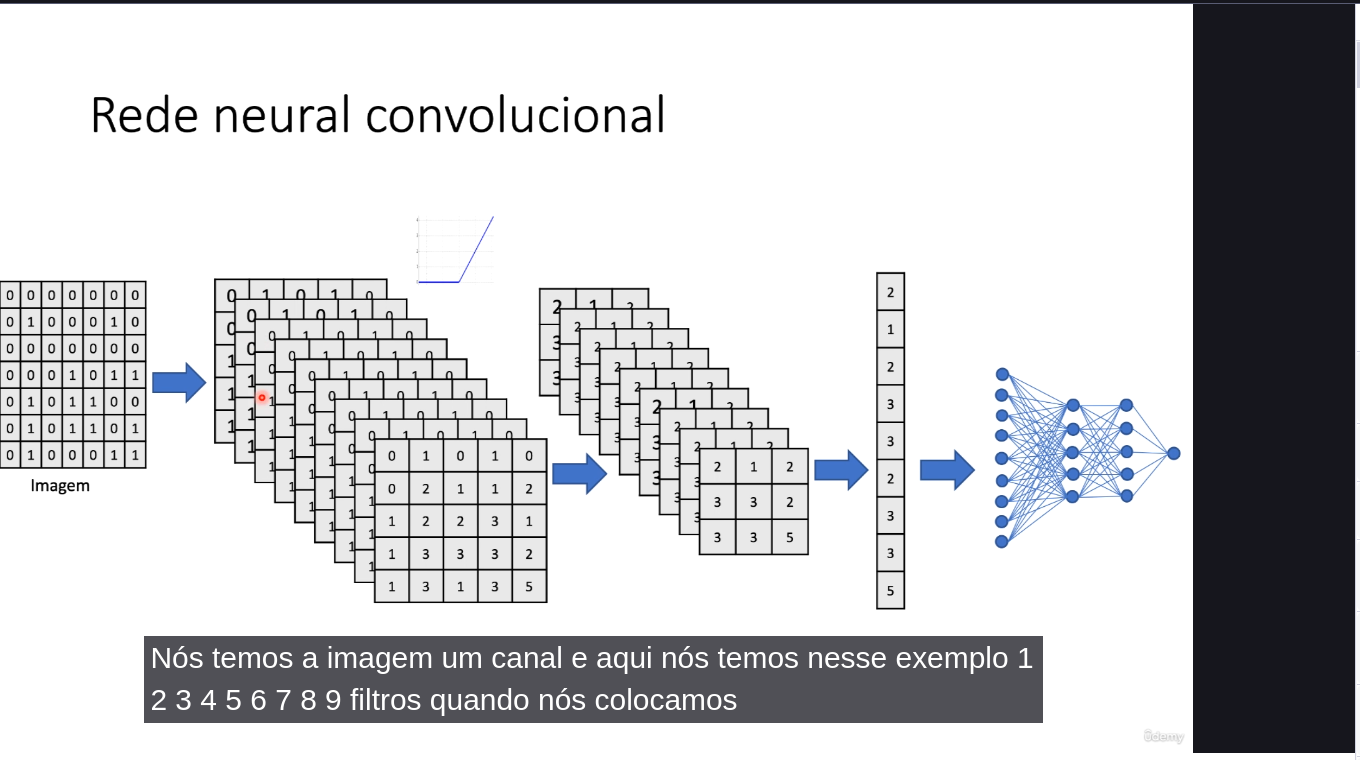

In [28]:
# primeira figura a imagem em matriz
# segunda 9 filtros (só que no script colocamos 32 filtros)
#  self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3,3))


# kernel_size=(3,3)
# etapa1 do operador de convolução se faz a multiplicação da imagem por um detector de características 

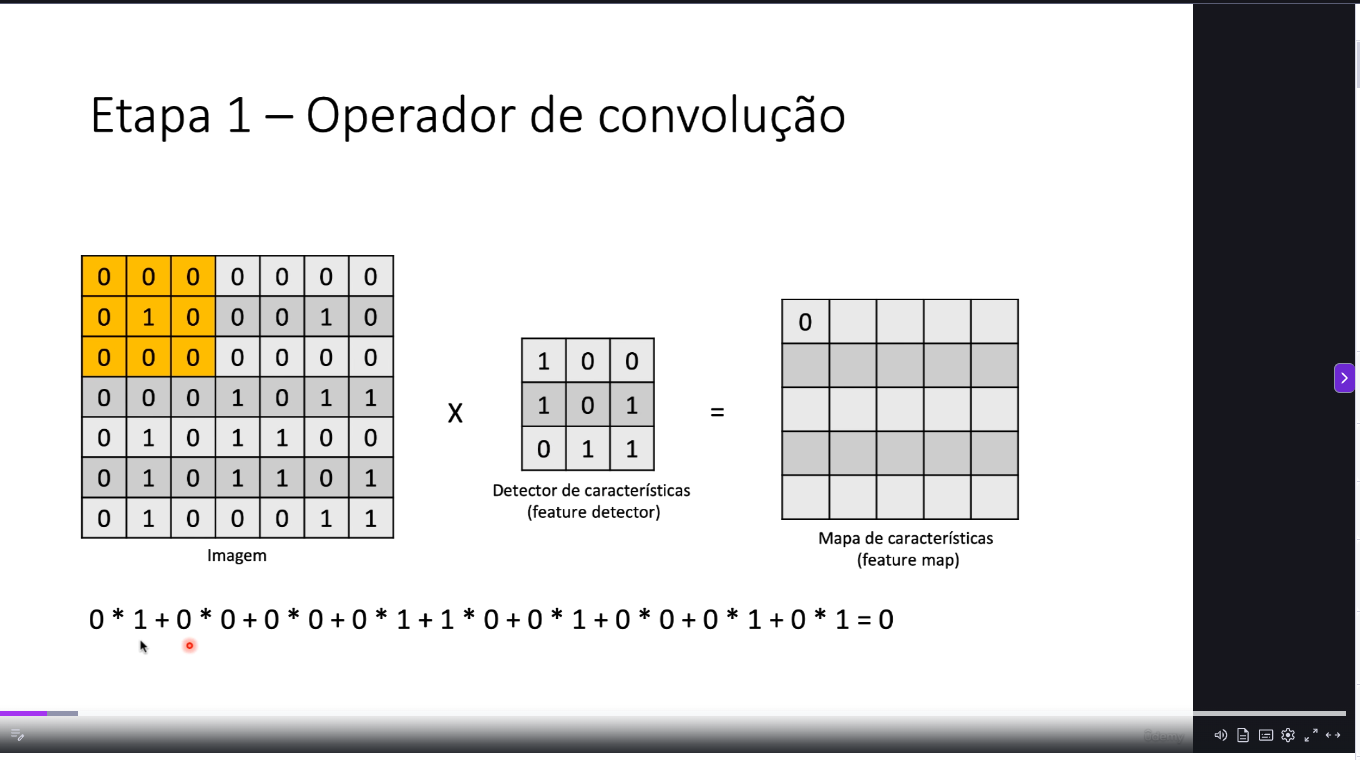

In [29]:
# vertical multiplica e soma com a matriz em horizontal

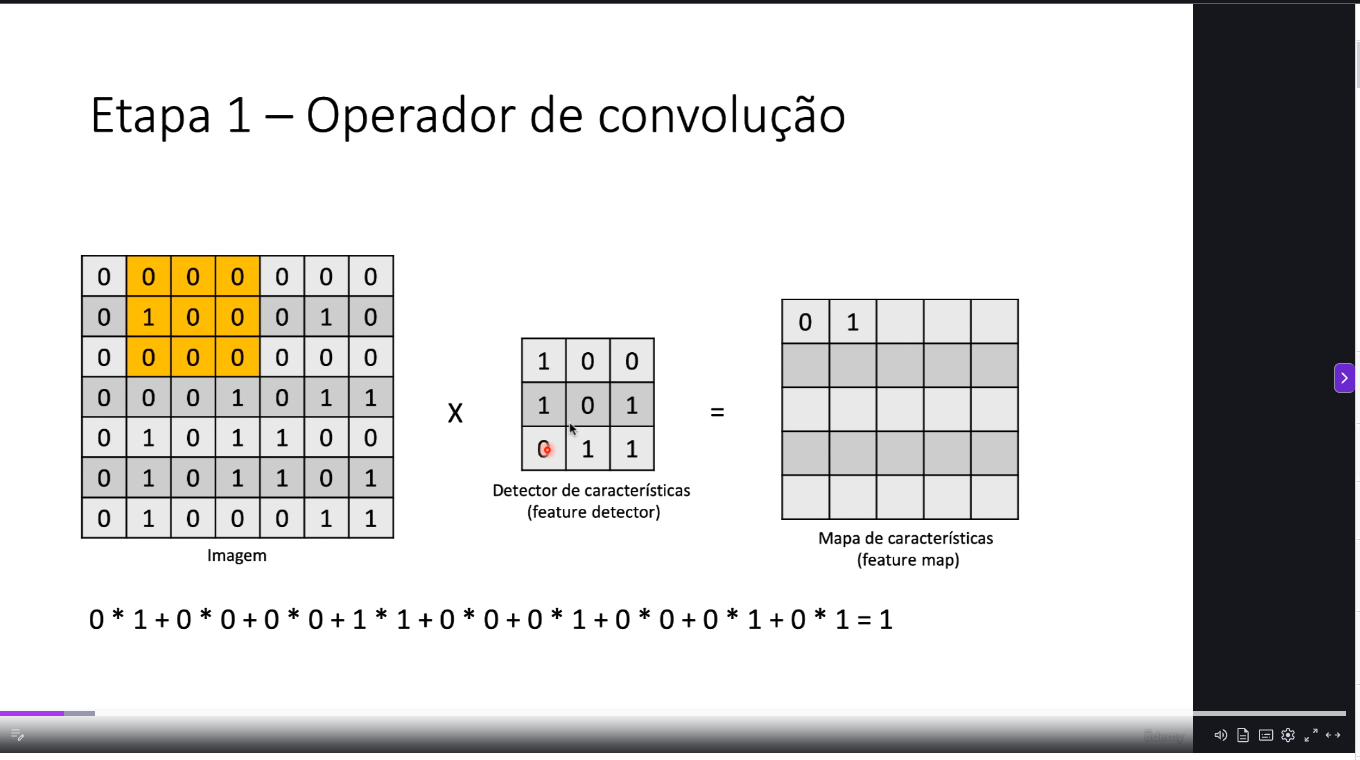

self.activation = nn.ReLU()

função Relu , que enfatiza a sombra da imagem 

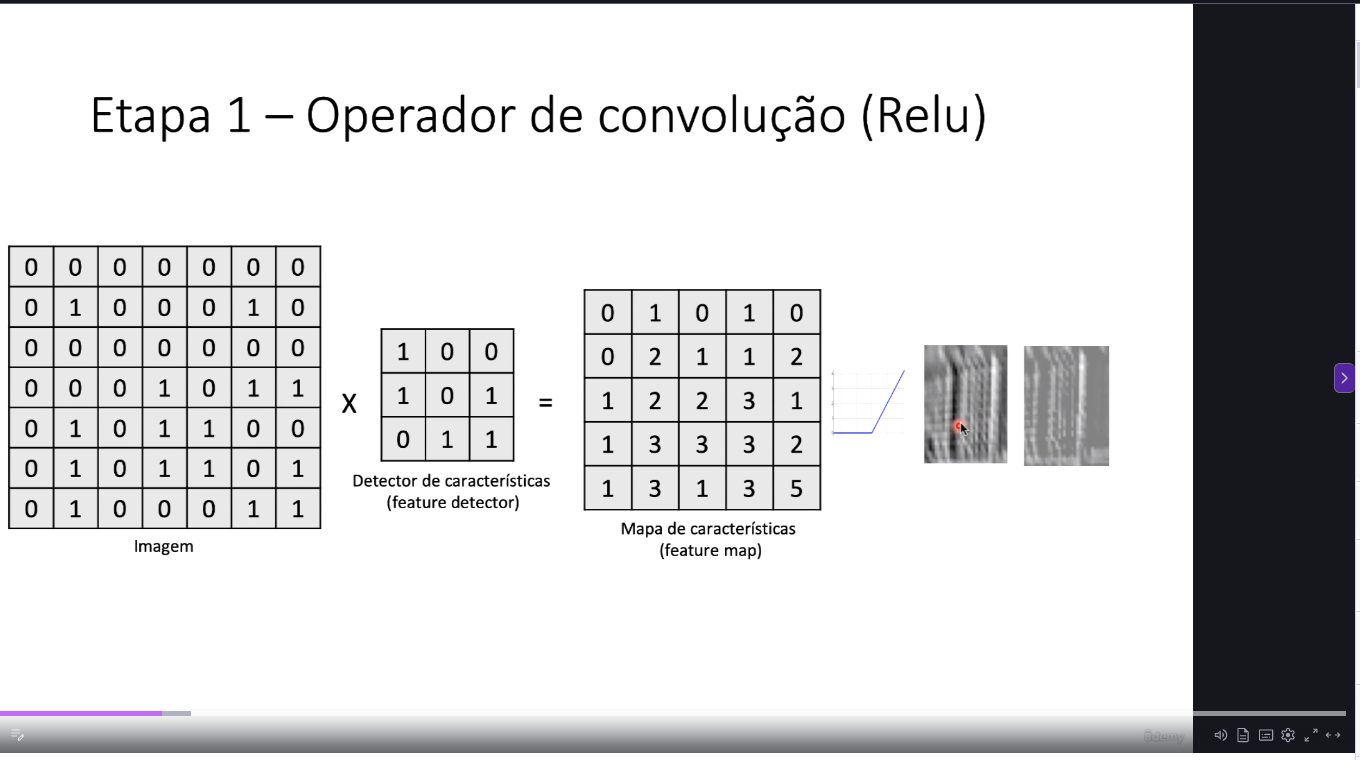

self.pool = nn.MaxPool2d(kernel_size = (2,2))

matriz 2x2

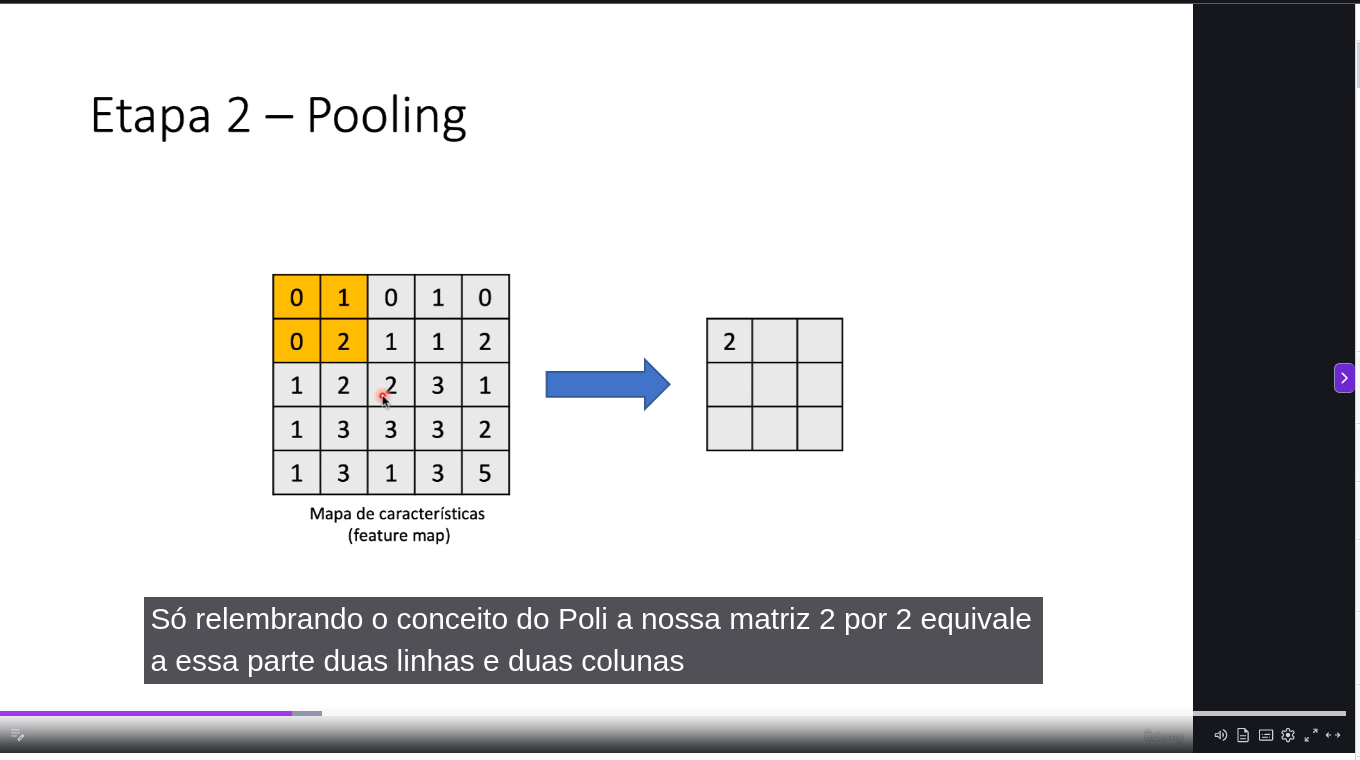


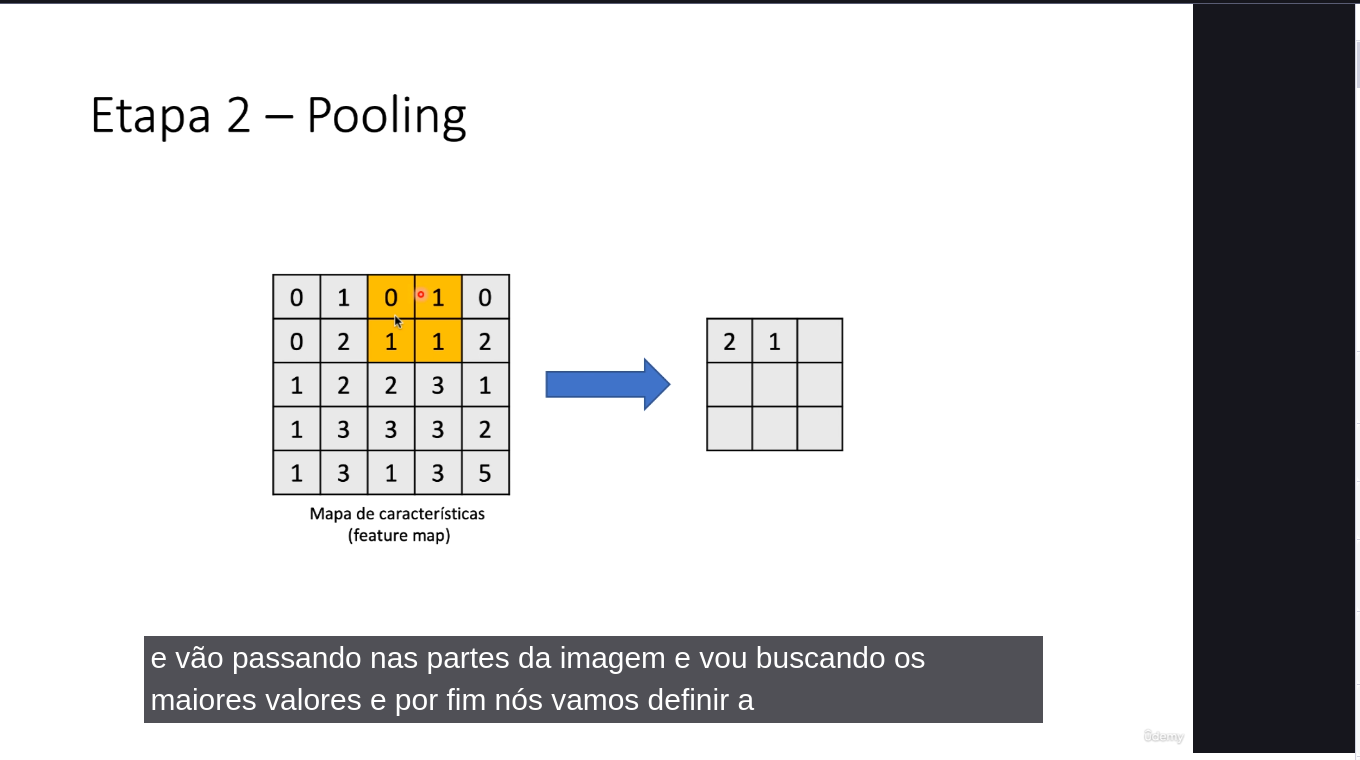

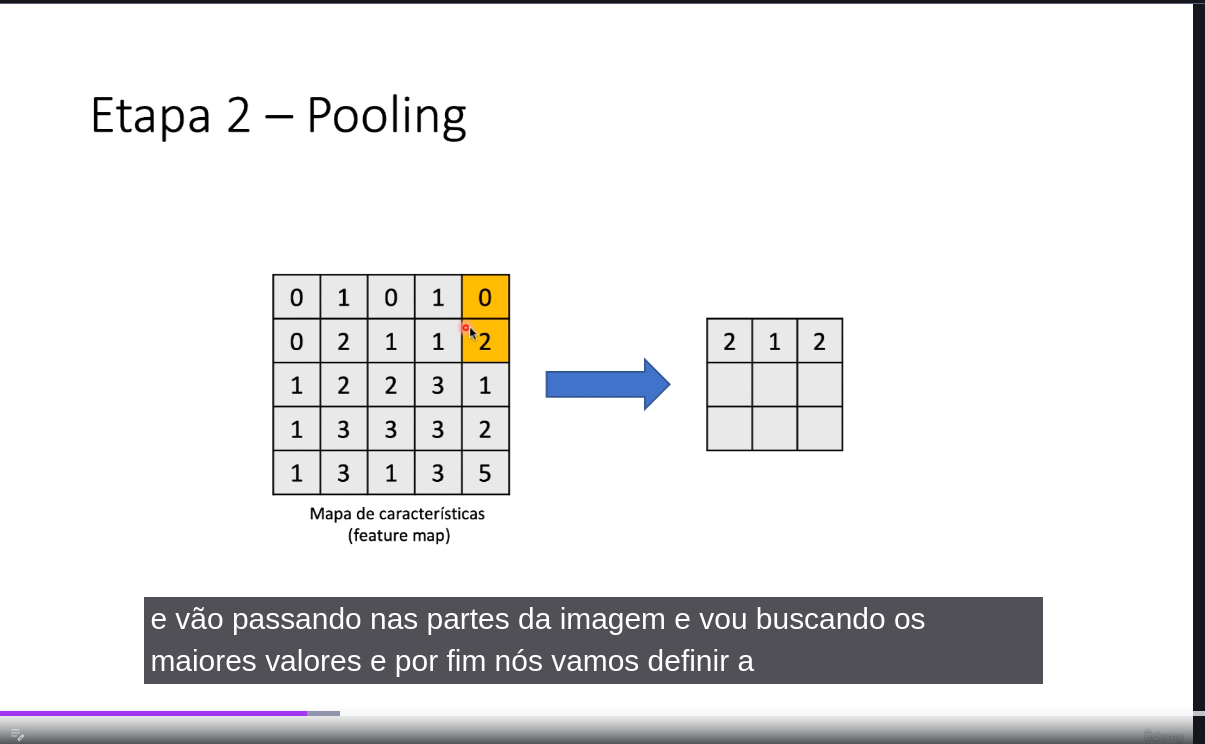




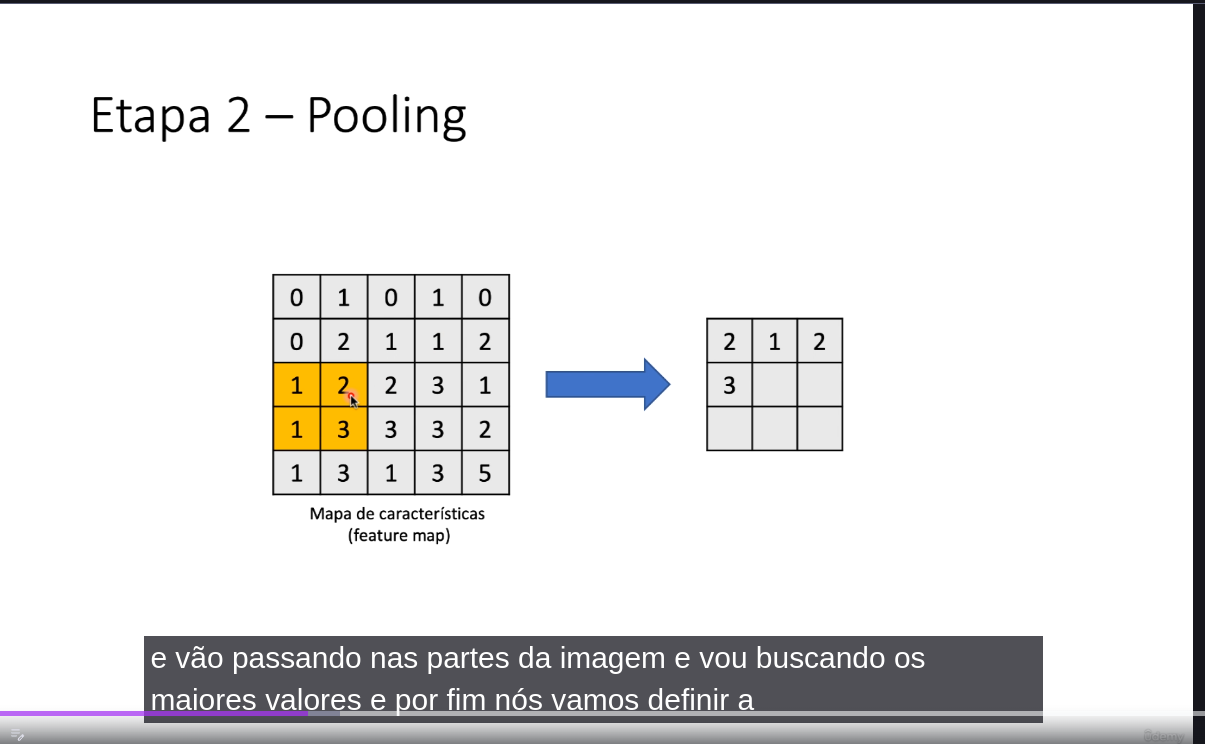




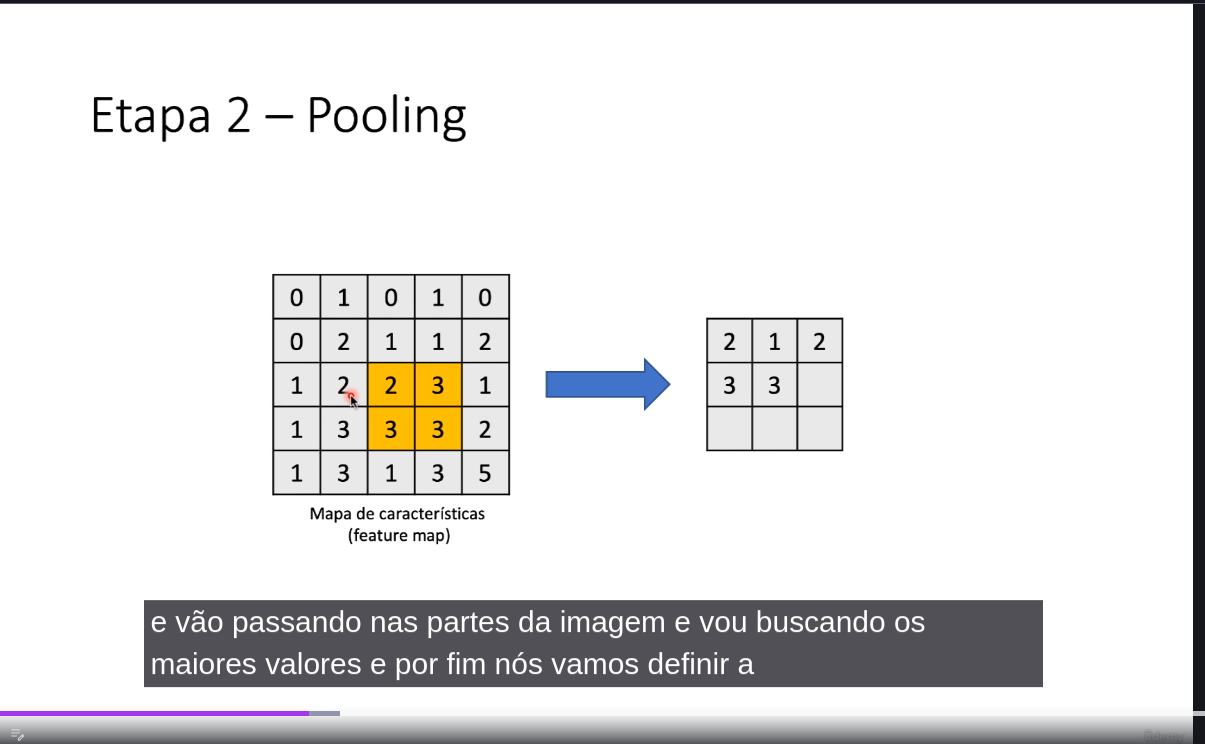

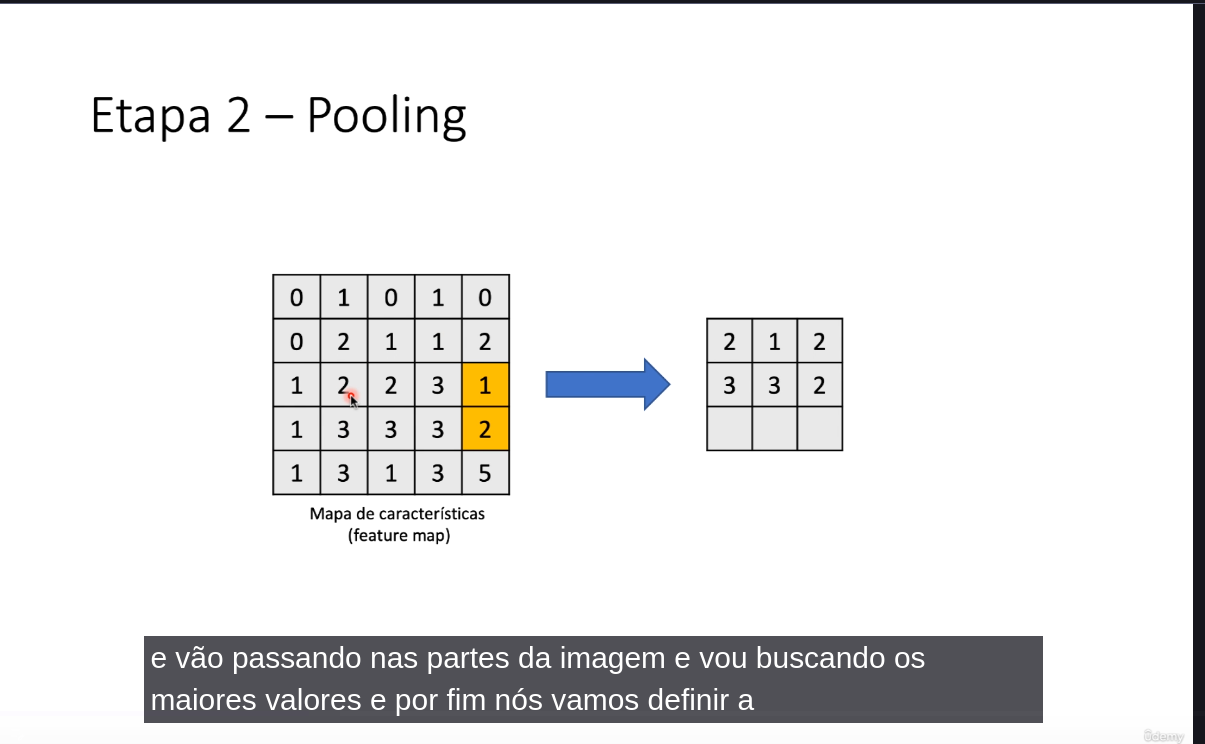

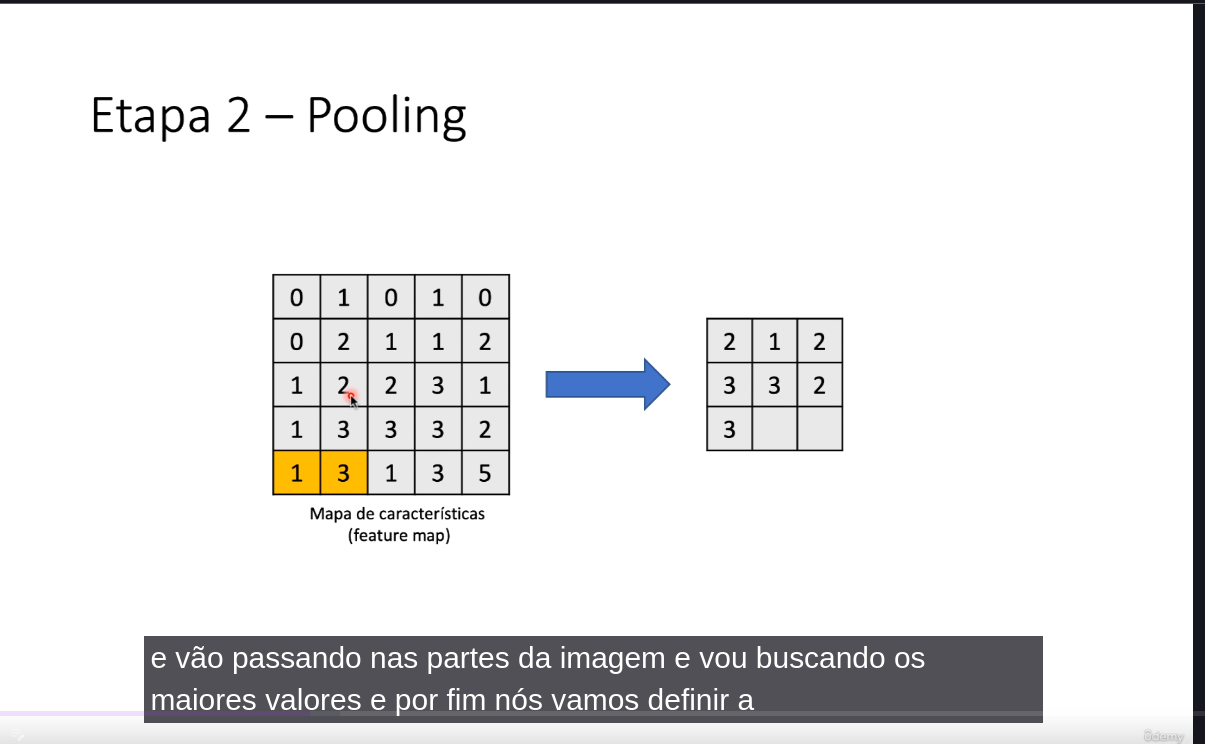

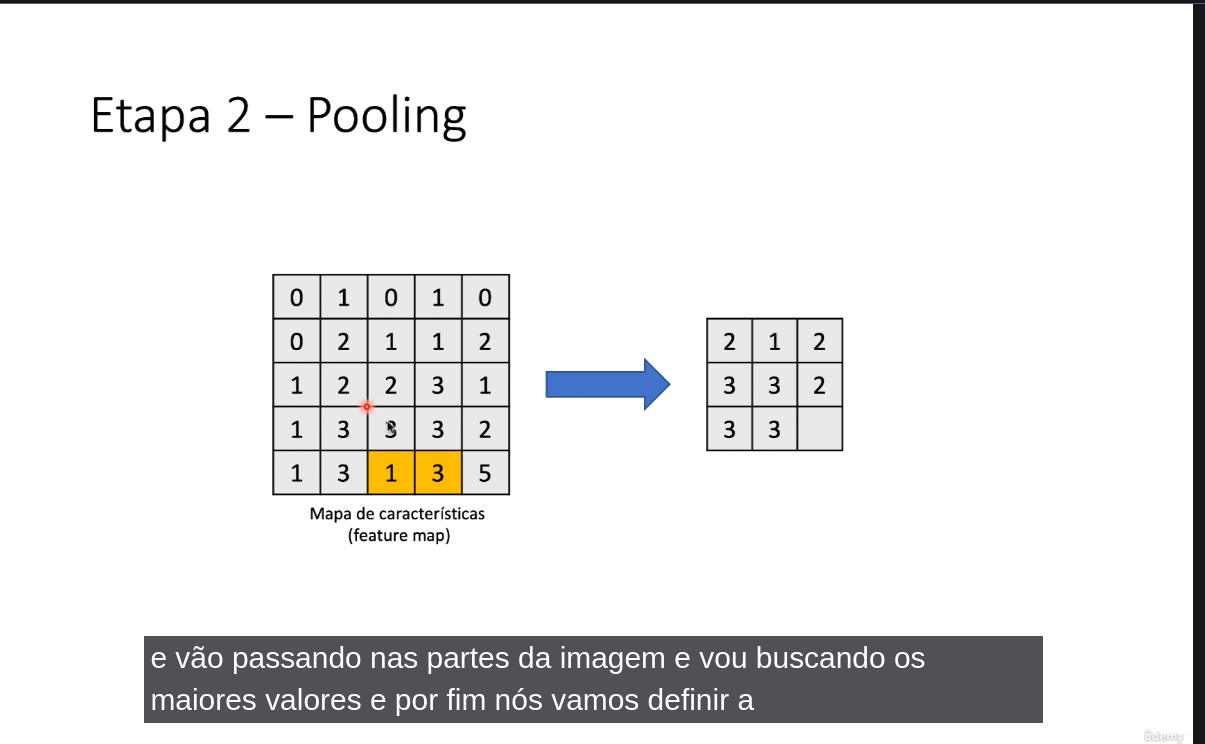


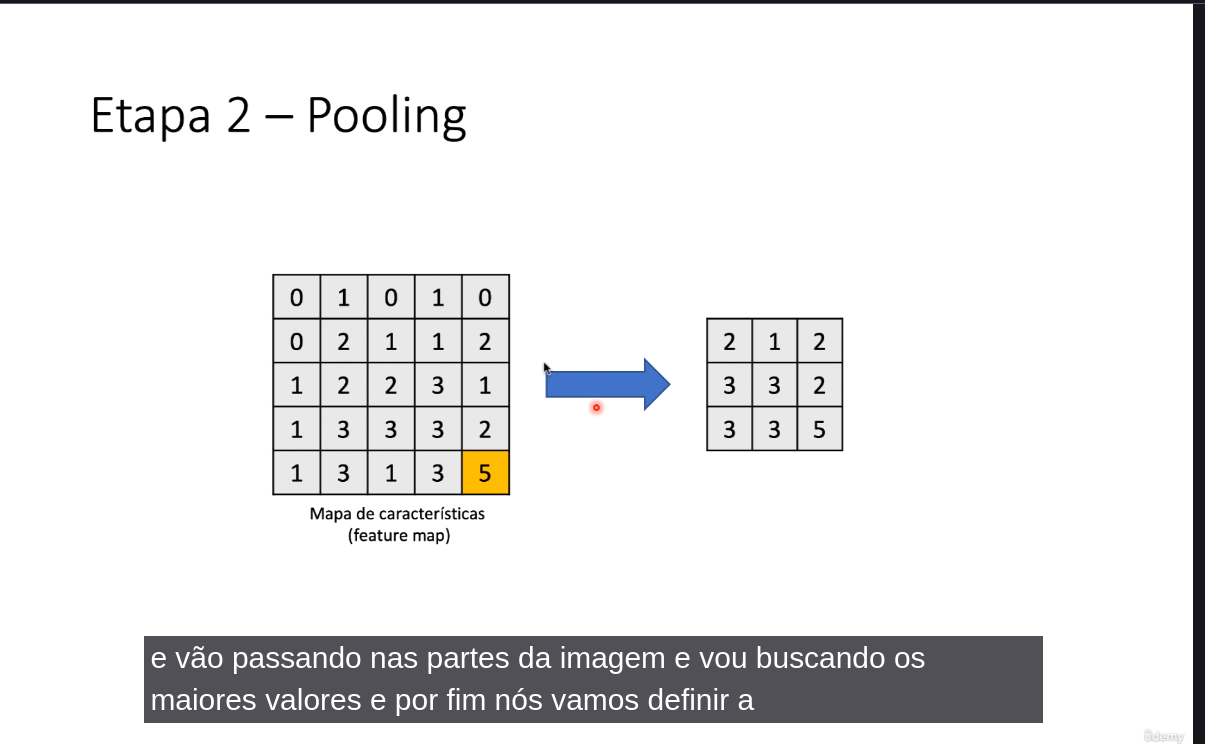

##### transformar a matriz em vetor  para a parte densa da rede neural 

self.flatten = nn.Flatten()

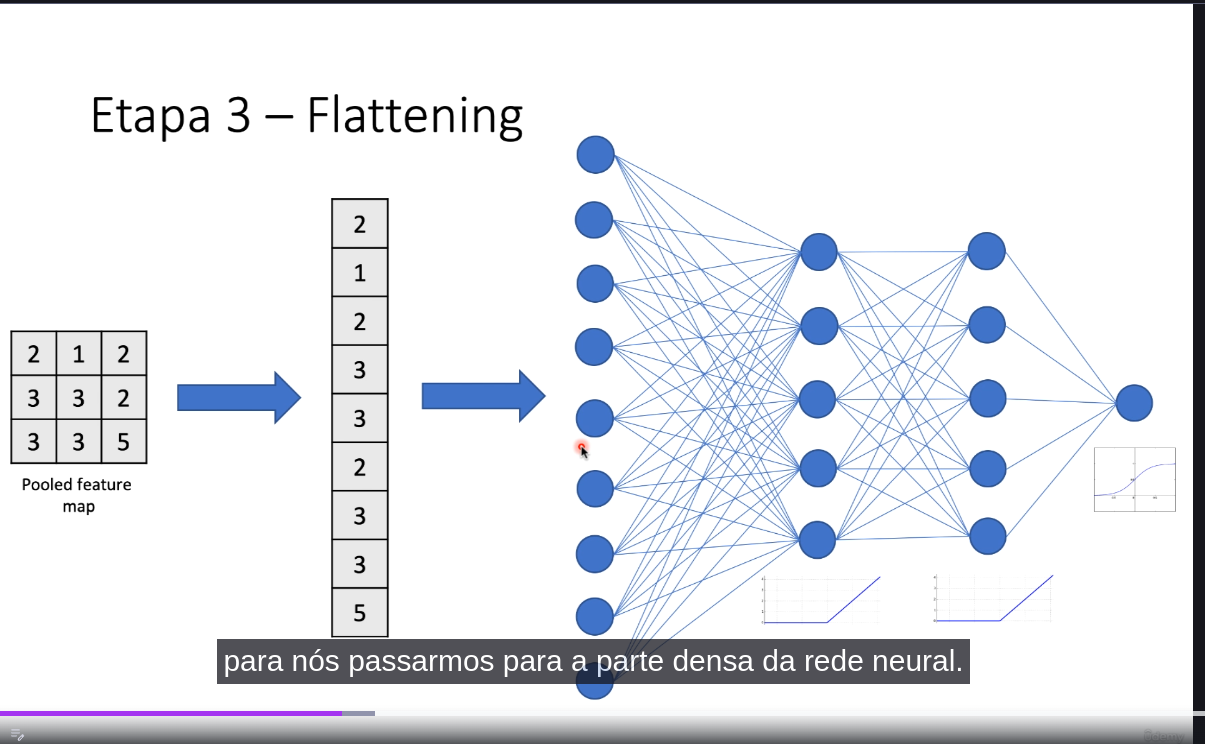


128 da camada oculta

128 neurônio da segunda camada oculta

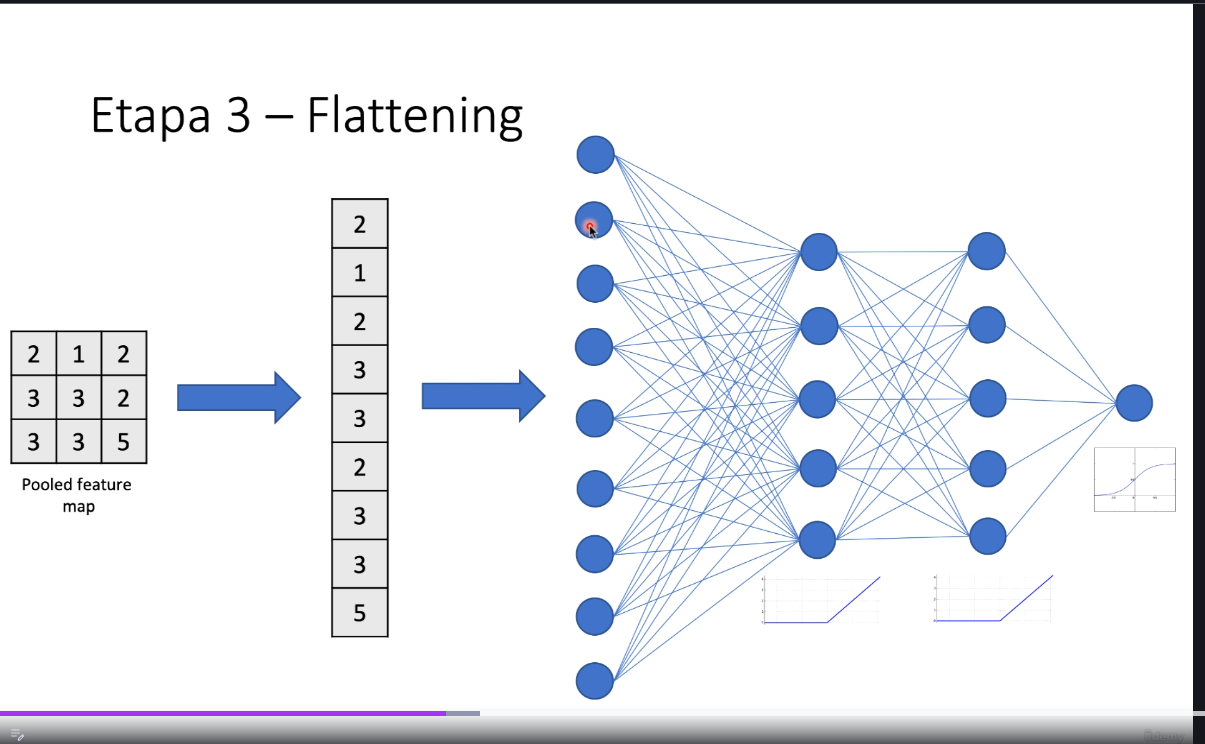

## stride de 1 a um 

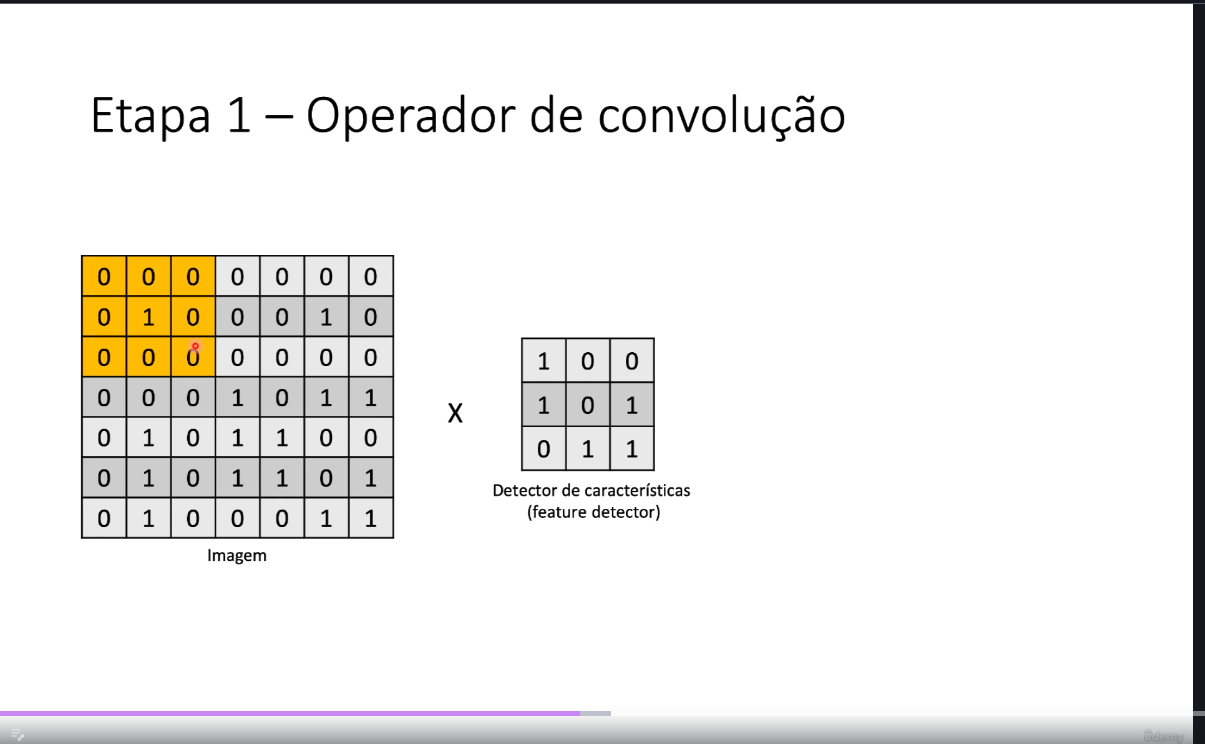


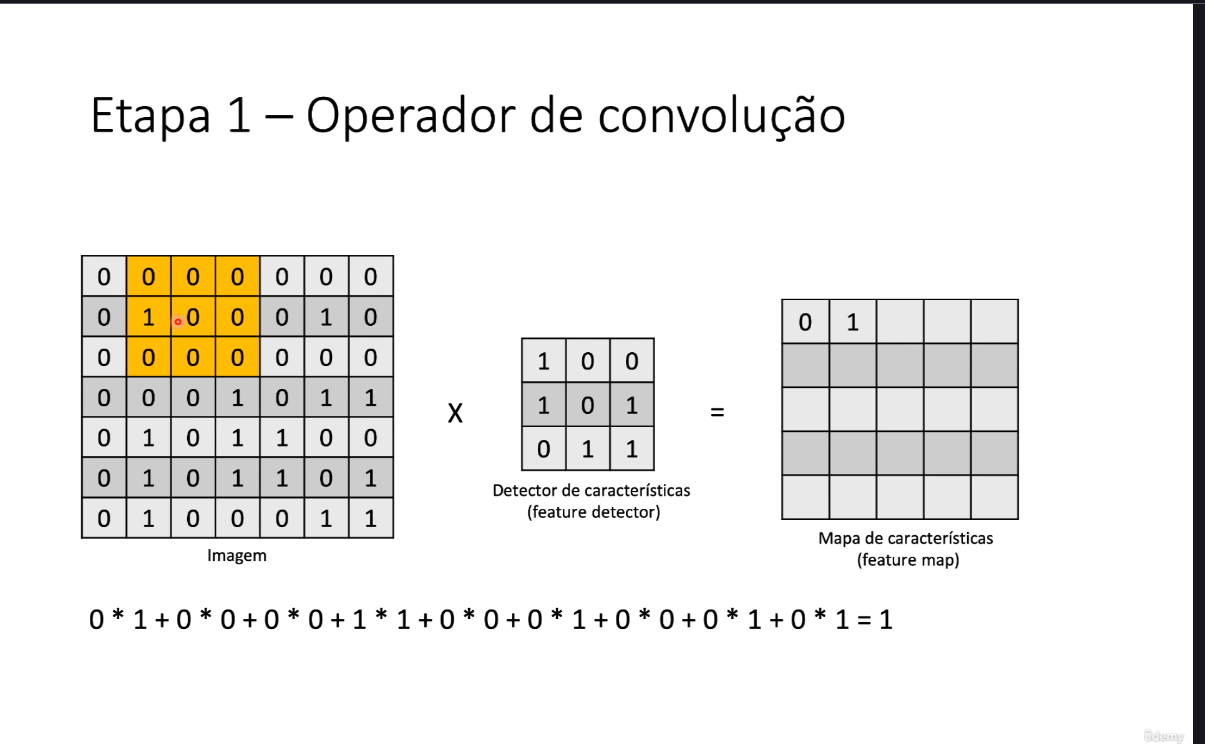


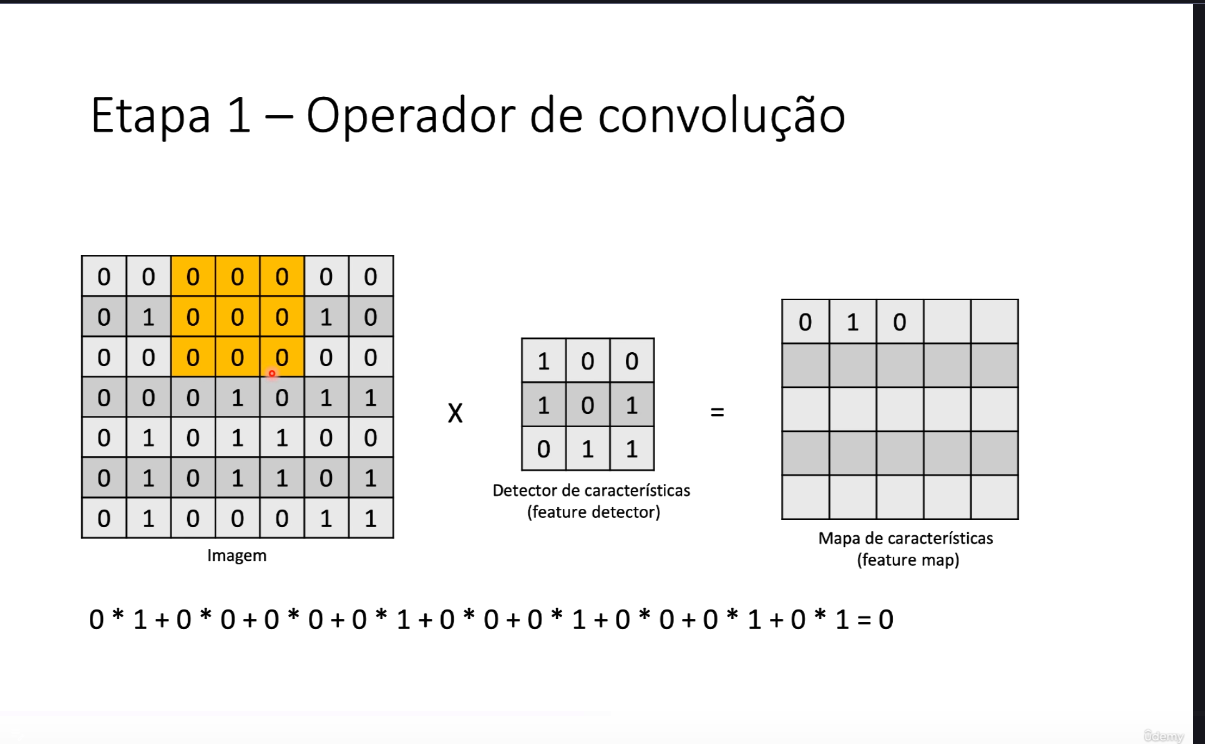


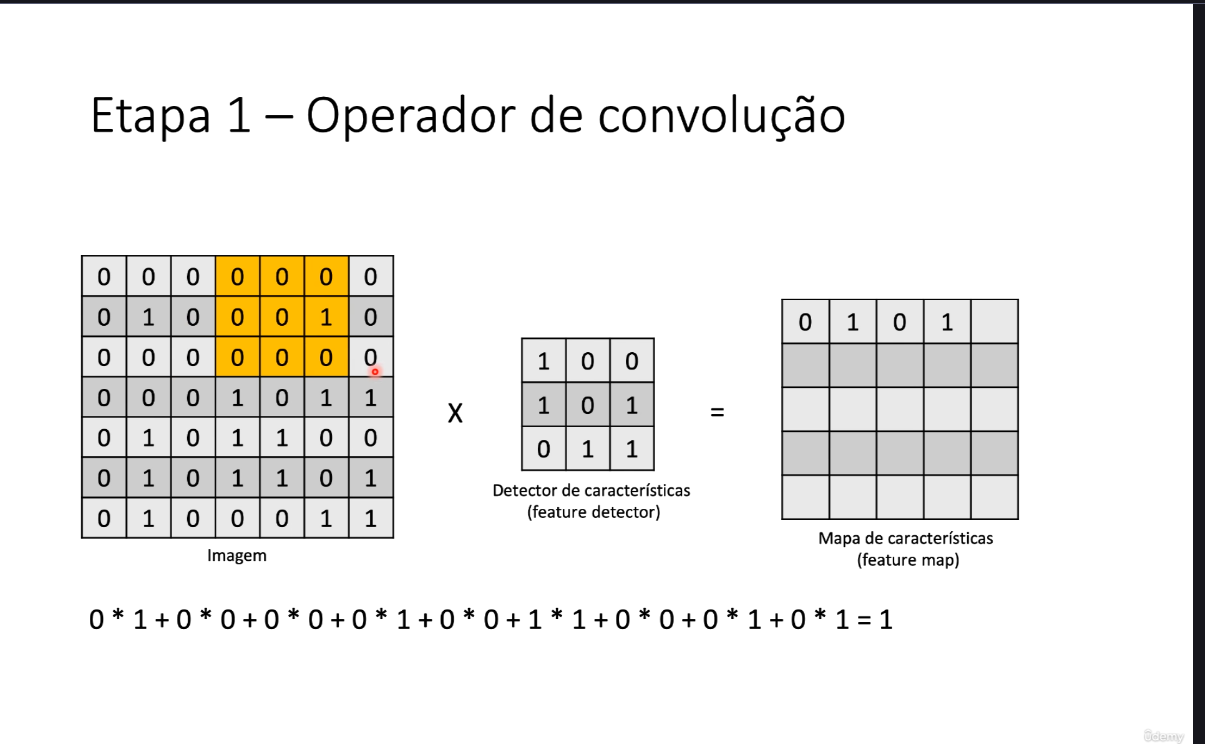


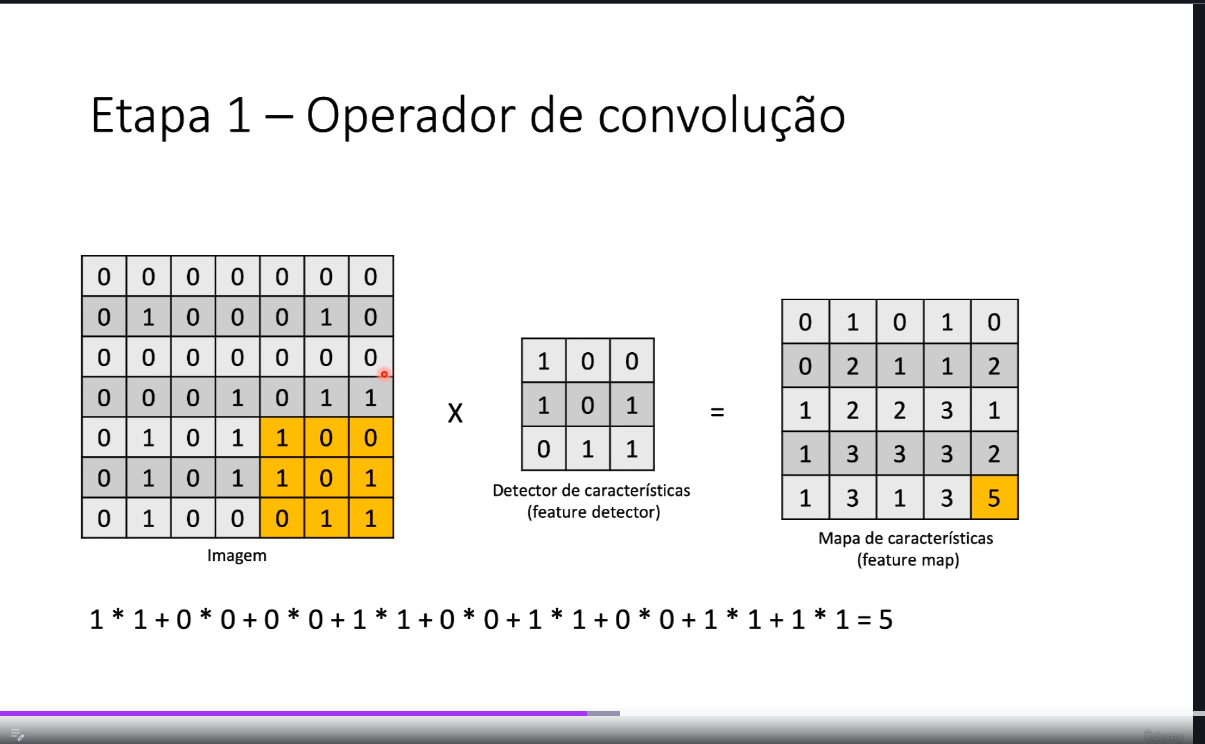

## pooling

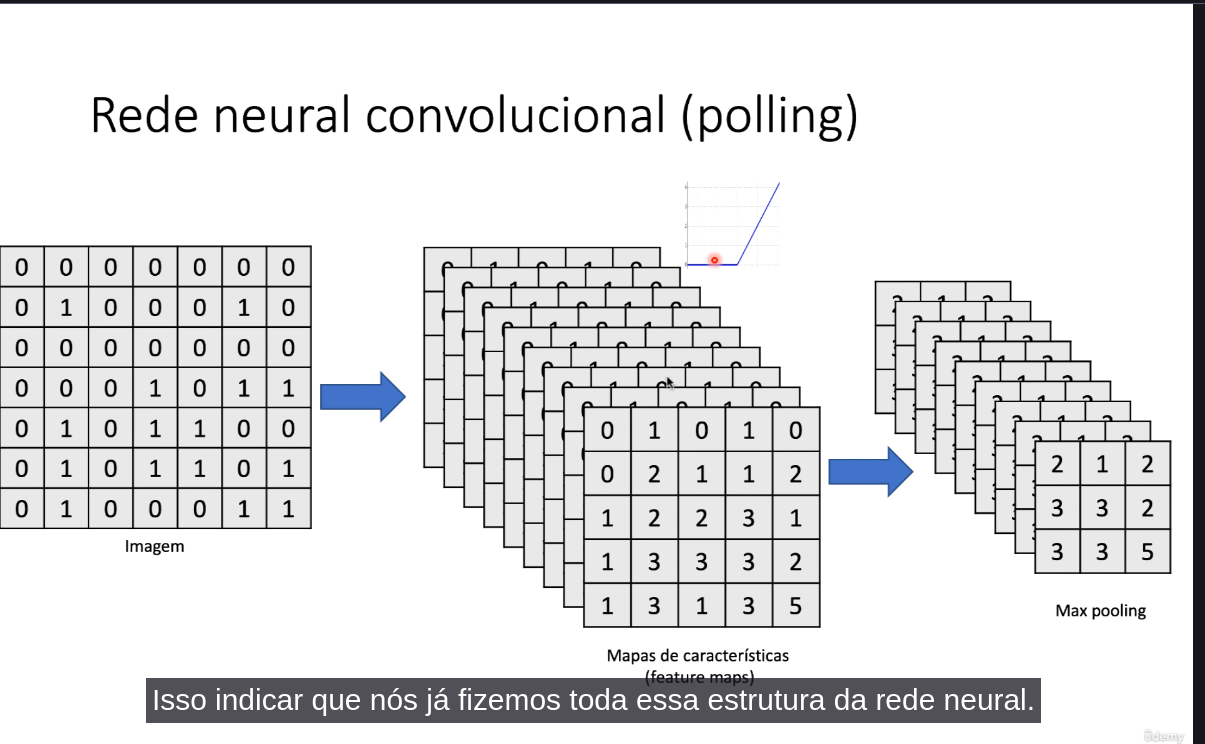

In [30]:
class classificador(nn.Module):
  def __init__(self):
    super().__init__()

    # ------------ ESTRUTURA DA PARTE da Rede neural convolucional  ----------------------------------- 
    # --- CAMADA CONVOLUCIONAL (Extração de Características) ---
    # self.conv1: Recebe imagem 1 canal (cinza), aplica 32 filtros 3x3. Sai: 32 mapas.   
    # Conv2d=> duas dimensões  | in_channels formato do dados de entrada, 1 canal (figura cinza), se fosse colorida as fotos seria in_channels=3
    # número de filtros out_channels=32 canais de saída (32 filtros)
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3,3))
    # self.conv2: Recebe 32 mapas, aplica mais 32 filtros. Refina a extração.
    self.conv2 = nn.Conv2d(32, 32, (3, 3)) # 32 filtros passados no primeiro parâmetro | depois o kernel size
    # nesta estrutura teremos apenas 2 camadas de convolução

    # ATIVAÇÃO: ReLU zera valores negativos (traz não-linearidade).      
    self.activation = nn.ReLU()
    # BATCH NORM: Normaliza os dados (escala 0-1) para o treino ser mais rápido/estável.      
    # batch normalization
    # batch lote
    # normalização dos dados dentro das camadas ocultas, 
    # valores do pixels de 0 a 255, para ficarem na escala de 0 a 1
    # processos nas camadas ocultas | num_features=32 por conta dos filtros da saída nas camadas de convolução.      
    self.bnorm = nn.BatchNorm2d(num_features=32)
    # POOLING: Reduz tamanho da imagem pela metade (Max seleciona o pixel mais forte).      
    self.pool = nn.MaxPool2d(kernel_size = (2,2))
    # FLATTEN: Achata a matriz 3D (Canais, H, W) em um vetor 1D para a rede densa.      
    # transformar a matriz em vetor
    self.flatten = nn.Flatten()
      
    # ----------- Rede Neural densa -------------------------------------      
    # -------------------------------------------------------------------
    # in_features=32 pixels*5*5 => 800 valores -> 128 da primeira camada oculta 
    # @ output = (input - filter + 1) / stride
    # reduzir a dimensionalidade da imagem | o stride anda de 1 a 1 pixel (stride automático é 1)
    # @ convolução 1: (28 - 3 + 1) / 1 = 26x26
    # Pool: reduz a dimensionalidade por 2 | self.pool = nn.MaxPool2d(kernel_size = (2,2))  
    # 26/2 x 26/2 => 13x13 
    # @ pooling 1: 13x13
    # convolução 2: (13 - 3 + 1) / 1 = 11x11
    # @ pooling 2: 5x5
    # pool divide por 2 11/2 x 11/2 => 5,5x5,5 ou 5x5 (pytorch não considera as bordas e usa o 5x5)  
    # (definimos os 32 como detecotres de características (num_features =32)
    # @ 5 * 5 * 32
    # por isso os in_features=32 pixels*5*5 => 800 valores
    # @ 800 -> 128 -> 128 -> 10
    # depois do pooling vem a primeira camada densa

    # camada de entrada 800 -> 128 neurônios da camada oculta-> 128 neurônios da segunda camada oculta--> 10
    # ----------- Rede Neural densa -------------------
    # primeira camada densa  (linear1)
    # in_features quantos neurônios chegam da camada de Flatten

    # --- REDE DENSA (Classificação Final) ---
    # Cálculo: Imagem 28x28 -> Conv1 -> Pool -> Conv2 -> Pool = Final 5x5.
    # Entrada: 32 filtros * 5px * 5px = 800 neurônios na entrada da Densa.
    self.linear1 = nn.Linear(in_features=32*5*5, out_features=128)
    # próxima camada densa linear2
    self.linear2 = nn.Linear(128, 128)
    # saída com camada densa, com saída de 10 neurônios
    # SAÍDA: 10 neurônios (um para cada classe, ex: números de 0 a 9). 
    self.output = nn.Linear(128, 10)
    # p = probabilidade, zerando os 20% dos neurônios
    self.dropout = nn.Dropout(p = 0.2)
    # DROPOUT: Desliga 20% dos neurônios aleatoriamente para evitar viciar (overfitting).

  # função forward  
  # conexão dentre as camadas
  def forward(self, X):
    # sequência das camadas
    # entrada dos dados de convolução
    # X = self.conv1(X)
    # primeiro ativação self.activation(self.conv1(X))
    # normaliza primeiro self.bnorm(self.activation(self.conv1(X)))
    # depois para a camada de pooling => self.pool(self.bnorm(self.activation(self.conv1(X))))

    # Fluxo: Conv -> Ativação -> Normalização -> Redução (repetido 2x)  
    X = self.pool(self.bnorm(self.activation(self.conv1(X))))
    X = self.pool(self.bnorm(self.activation(self.conv2(X))))

    # Prepara para a Densa     
    X = self.flatten(X)
      
    # segunda parte densa
    # Fluxo Densa: Linear -> Ativação -> Dropout (evita decoreba)   
    X = self.dropout(self.activation(self.linear1(X)))
    X = self.dropout(self.activation(self.linear2(X)))

    # Camada final de decisão
    X = self.output(X)

    return X

In [31]:
# rede neural
net = classificador()
# critério , CrossEntropyLoss() aplicação do soft max
criterion = nn.CrossEntropyLoss()
# otimizar
optimizer = optim.Adam(net.parameters())

## Etapa 4: Treinamento do modelo

In [32]:
device = torch.device('cuda') if torch.cuda.is_available else torch.devide('cpu')
device # selecionar o device
# não temos o RuntimeError: Found no NVIDIA driver on your system. 
# Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

device(type='cuda')

In [33]:
device = torch.device('cpu') if torch.cuda.is_available else torch.devide('cuda')
device # selecionar o device

device(type='cpu')

In [34]:
# mandar a rede definida para o device
net.to(device)

classificador(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (activation): ReLU()
  (bnorm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=800, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [35]:
# faremos o treinamento e a validação com esse mesmo loop
def training_loop(loader, epoch):
    # Inicializamos os acumuladores para calcular a média ao final da época
    running_loss = 0.
    running_accuracy = 0.
    
    # O enumerate percorre o loader, que entrega os dados em pacotes (batches)
    for i, data in enumerate(loader): # batch_size com 128 registros loader
        # 1. PREPARAÇÃO: inputs (pixels) e labels (classe real/gabarito)
        # inputs é o pixels, labels são as respostas
        inputs, labels = data
        # Enviamos para a GPU/CPU configurada (device)
        # mandamos os inputs e o labels para a cpu
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 2. ZERAR GRADIENTES: Limpa resíduos do cálculo anterior para não acumular
        # zeramos o gradiente
        optimizer.zero_grad()

        # 3. FORWARD: Passa a imagem pela rede (chama o método forward da classe)
        # fazemos a previsão, pela rede neural, passamos o pixel
        # com cada classe pertence
        # implícito o foward no net()
        outputs = net(inputs)
        
        # 4. LOSS (ERRO): Compara o que a rede chutou (outputs) com o real (labels)
        # critério, com a previsão outputs, e os dados reais labels
        loss = criterion(outputs, labels)

        # 5. BACKPROPAGATION: O PyTorch calcula quanto cada peso contribuiu para o erro
        # olhando o Backpropagation
        #O Backpropagation (retropropagação do erro) é o algoritmo fundamental para treinar redes neurais profundas,
        # ajustando pesos e bias para minimizar erros de previsão.
        loss.backward()
        # atualizando os pesos

        # 6. ATUALIZAÇÃO: O otimizador ajusta os pesos (weights e bias) para errar menos
        optimizer.step()
        # Acumula o valor do erro (loss.item() extrai o número do tensor)
        # somando o learning loss, somando o dado final e o resultado. 
        running_loss += loss.item()

        # --- CÁLCULO DE ACURÁCIA (O quanto estamos acertando) ---        
        # Softmax: Transforma os outputs em probabilidades (0 a 1)
        
        # calcular a acurácia
        # ps achar a probabilidade
        ps = F.softmax(outputs)
        # k =  para ter o resultado com o maior valor, 
        #  dim = 1 é o processamento por coluna
        
        # topk(1): Pega o maior valor (a classe que a rede tem mais certeza)
        top_p, top_class = ps.topk(k = 1, dim = 1)

        # Comparamos a previsão com o real. view() garante que ambos tenham o mesmo formato
        # top_class.shape vetor bool, indicando o classificador se acertou ou errou as previsões
        # deixar no mesmo formato
        equals = top_class == labels.view(*top_class.shape)

        # Média de acertos no batch: transformamos True/False em 1.0/0.0 e tiramos a média
        # número de amostras média
        accuracy = torch.mean(equals.type(torch.float))

        # somando as acurácias
        running_accuracy += accuracy

        # Impressão dinâmica (substitui a linha no console durante o loop)
        # Imprimindo os dados referentes a este loop
        print('\rÉpoca {:3d} - Loop {:3d} de {:3d}: perda {:03.2f} - precisão {:03.2f}'.format(epoch + 1, i + 1, len(loader), loss,
                                   accuracy), end = '\r')

    # --- FINAL DA ÉPOCA ---
    # Mostra a média de erro e acerto de todos os pacotes processados
    # Imprimindo os dados referentes a esta época
    print('\rÉPOCA {:3d} FINALIZADA: perda {:.5f} - precisão {:.5f}'.format(epoch+1, running_loss/len(loader),
                     running_accuracy/len(loader)))

In [36]:
for epoch in range(5): # treinamento por 5 épocas
  print('Treinando...')
  training_loop(train_loader, epoch)
  net.eval() # rede neural mudada para modo de avaliação .eval()
  # não ajusta os pesos, sem usar o dropout 
  print('Validando...') # ou avaliando para a rede neural, final de cada época, teste inteiro, com a acurácia
  training_loop(test_loader, epoch)
  net.train() # depois colocamos a rede neural no modo treino | sem isso ele considera em forma de teste

Treinando...


/tmp/ipykernel_25840/3421096304.py:48: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  ps = F.softmax(outputs)


ÉPOCA   1 FINALIZADA: perda 0.16746 - precisão 0.950429
Validando...
ÉPOCA   1 FINALIZADA: perda 0.13602 - precisão 0.960740
Treinando...
ÉPOCA   2 FINALIZADA: perda 0.05506 - precisão 0.984149
Validando...
ÉPOCA   2 FINALIZADA: perda 0.07204 - precisão 0.978240
Treinando...
ÉPOCA   3 FINALIZADA: perda 0.03968 - precisão 0.988209
Validando...
ÉPOCA   3 FINALIZADA: perda 0.04432 - precisão 0.986850
Treinando...
ÉPOCA   4 FINALIZADA: perda 0.03065 - precisão 0.990659
Validando...
ÉPOCA   4 FINALIZADA: perda 0.03603 - precisão 0.988730
Treinando...
ÉPOCA   5 FINALIZADA: perda 0.02874 - precisão 0.991459
Validando...
ÉPOCA   5 FINALIZADA: perda 0.04340 - precisão 0.987050


In [37]:
# perda é o erro e a precisão o acerto
# o idela é considerar o valor da validação

In [38]:
# final pegar a imagem e fazer a classificação

In [39]:
# percentual de acerto precisão 0.987050

## Etapa 5: Avaliação do modelo

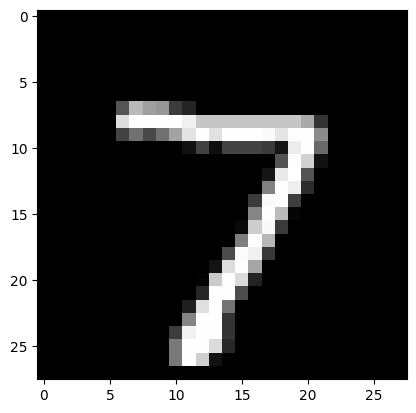

In [40]:
# buscar a primeira imagem [0][0]
imagem = next(iter(test_loader))[0][0].view(28,28)
plt.imshow(imagem, cmap='gray')

In [41]:
# colocar a imagem em um formato para passar para a rede neural
# (1, 1, 28, 28) - (batch_size, número de canais, altura, largura)  # padrão no torch
imagem.shape # converter a imagem no formato (batch_size, número de canais, altura, largura)

torch.Size([28, 28])

In [42]:
imagem = imagem.view(1, 1, 28, 28) # view para redimensionar
imagem.shape

torch.Size([1, 1, 28, 28])

In [43]:
net.eval() # a rede neural estará em forma de avaliação
imagem = imagem.to(device)

In [44]:
imagem

tensor([[[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [45]:
# a imagem foi mandada para a gpu ou cpu

In [46]:
# vamos fazer a previsão pelo forward e net rede neural
previsao = net.forward(imagem)

visualizar a variável previsão

In [47]:
previsao # 10 valores, cada uma para uma das classes

tensor([[-3.5129, -1.3607, -0.8840, -0.1360, -3.3777, -4.7967, -8.6812,  9.4754,
         -4.2575, -2.7872]], grad_fn=<AddmmBackward0>)

In [48]:
# formato logits, não temos em probabilidade

In [49]:
# previsão em probabilidade
previsao = F.softmax(previsao)

/tmp/ipykernel_25840/3286127833.py:2: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  previsao = F.softmax(previsao)


In [50]:
previsao # visualização em probabilidade

tensor([[2.2867e-06, 1.9674e-05, 3.1690e-05, 6.6953e-05, 2.6177e-06, 6.3336e-07,
         1.3020e-08, 9.9987e-01, 1.0860e-06, 4.7245e-06]],
       grad_fn=<SoftmaxBackward0>)

In [51]:
# acessar na forma de teste
previsao_final = previsao.cpu().detach().numpy()

In [52]:
# formato numpy ou array
previsao_final

array([[2.2867357e-06, 1.9673933e-05, 3.1690208e-05, 6.6952925e-05,
        2.6176706e-06, 6.3335551e-07, 1.3020383e-08, 9.9987030e-01,
        1.0860207e-06, 4.7244866e-06]], dtype=float32)

In [53]:
# valor real da classe, índice com o maior valor
resultado_final = np.argmax(previsao_final)

In [54]:
resultado_final

7

In [55]:
#resultado, o valor correto tem que ser 7

Mais exemplos

In [56]:
# --- INTERPRETANDO OUTPUTS ---

# Logits: O tensor bruto que você postou.
# Argmax: Retorna o índice do maior valor (a classe).
# Dim=1: Indica que a busca deve ser feita nas colunas (nas classes).

Para ver as classes a partir desse tensor (que chamamos de Logits), você precisa descobrir qual é o índice do maior valor dentro dele.

No seu caso, o valor 9.4754 é o maior. Se contarmos da esquerda para a direita (começando do 0), ele está na posição 7. Portanto, a classe prevista é a 7.

Aqui estão as três formas de extrair isso automaticamente via código:

1. Usando o torch.argmax (O mais direto)

apenas saber o número da classe:

In [60]:
# Supondo que seu tensor se chame 'outputs'. no caso é previsao
previsao_teste = torch.argmax(previsao, dim=1)
print(previsao_teste) 
# Resultado: tensor([7])

tensor([7])


2. Usando o topk (Como no seu script)

A classe e também o valor de "confiança" (o logit):

In [63]:
valores, classes = previsao.topk(k=1, dim=1) # Supondo que seu tensor se chame 'outputs'. no caso é previsao
print(classes)
# Resultado: tensor([[7]])

tensor([[7]])


3. Transformando em Probabilidades (Humanamente legível)

Como os valores estão brutos (negativos e positivos altos), use o Softmax para ver as chances em porcentagem:

In [64]:
import torch.nn.functional as F

probabilidades = F.softmax(previsao, dim=1)
print(probabilidades)
# O índice 7 terá algo próximo de 0.99 (99% de certeza)

tensor([[0.0853, 0.0853, 0.0853, 0.0853, 0.0853, 0.0853, 0.0853, 0.2319, 0.0853,
         0.0853]], grad_fn=<SoftmaxBackward0>)


In [65]:
valores, indices = torch.max(previsao, dim=1)

print(f"Maior valor (Logit): {valores}")
print(f"Índice (Classe): {indices}")

Maior valor (Logit): tensor([0.9999], grad_fn=<MaxBackward0>)
Índice (Classe): tensor([7])
